### Import necessary libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

### Create a function to display the image in a larger size

In [4]:
def display(img,cmap=None):
    plt.figure(figsize = (8,8))
    plt.imshow(img,cmap = cmap)

### Read 'coins_image.jpg' with cv2

In [6]:
img = cv2.imread('coins_image.jpg')

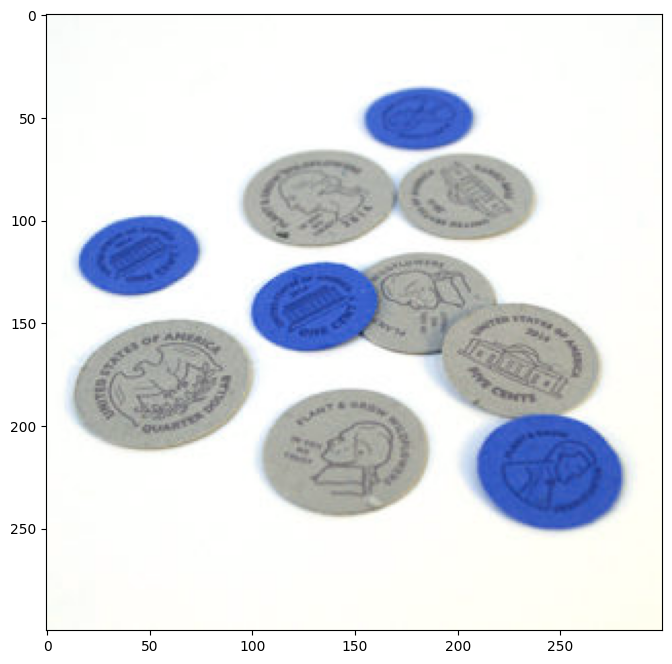

In [7]:
display(img)

### Apply Median Blur

In [9]:
img = cv2.medianBlur(img,25)

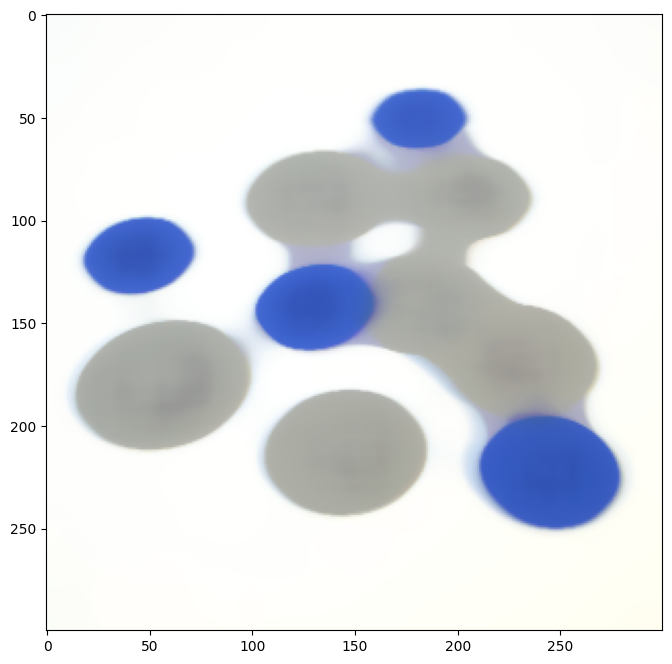

In [10]:
display(img)

### Convert to Grayscale

In [12]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

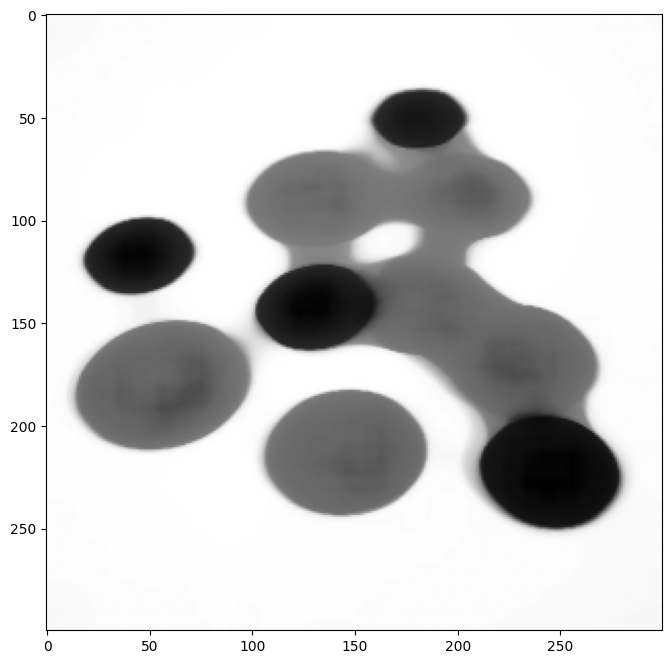

In [13]:
display(gray, cmap = 'gray')

### Apply threshold (Inverse binary with OTSU)

In [15]:
ret, img_thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

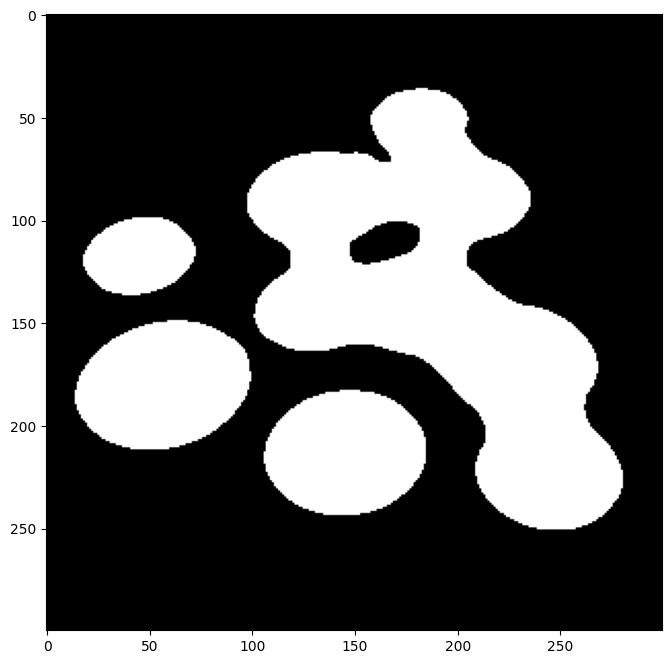

In [16]:
display(img_thresh, cmap = 'gray')

### Remove noise with the help of a morphological operator

In [18]:
kernel = np.ones((3,3))
opening = cv2.morphologyEx(img_thresh, cv2.MORPH_OPEN,kernel,iterations = 2)

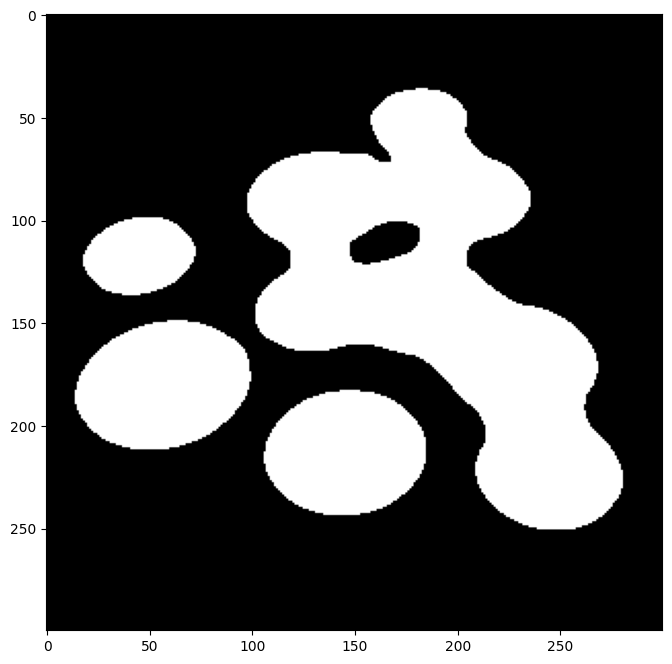

In [19]:
display(opening, cmap = 'gray')

### Grab background that you are sure of

In [21]:
sure_bg = cv2.dilate(opening,kernel,iterations = 3)

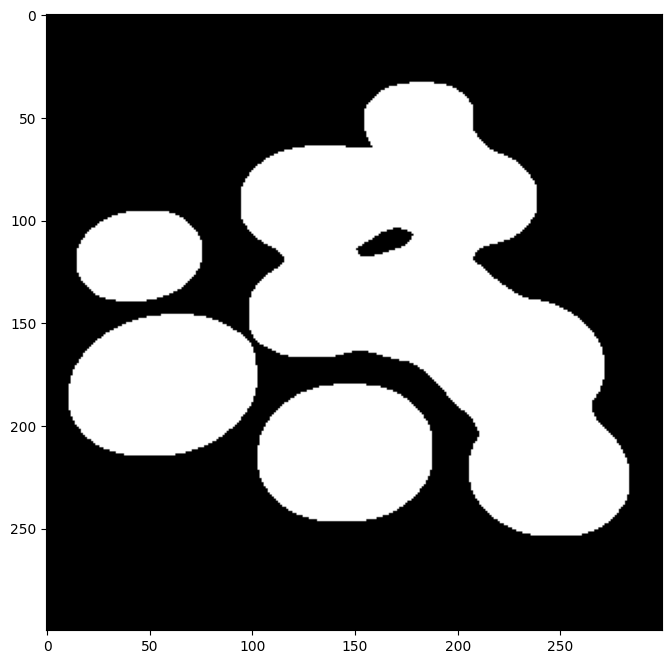

In [22]:
display(sure_bg, cmap = 'gray')

### Find sure Foreground

In [24]:
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)

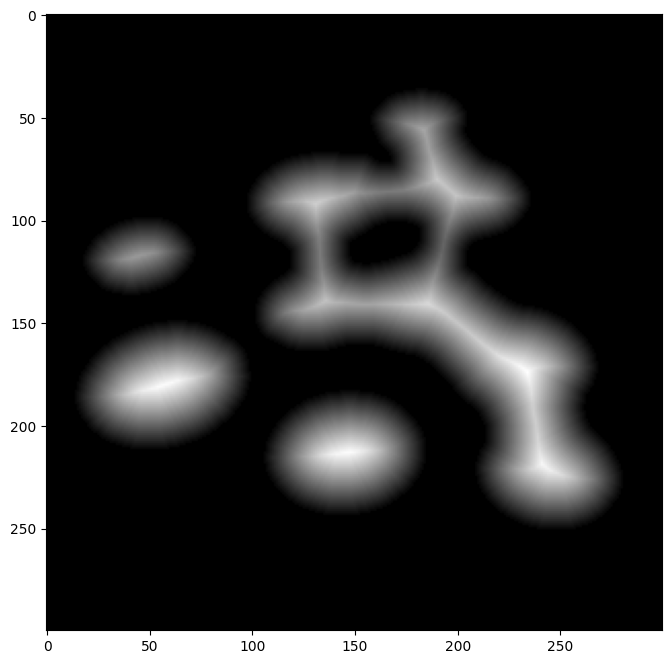

In [25]:
display(dist_transform, cmap = 'gray')

In [26]:
ret, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)

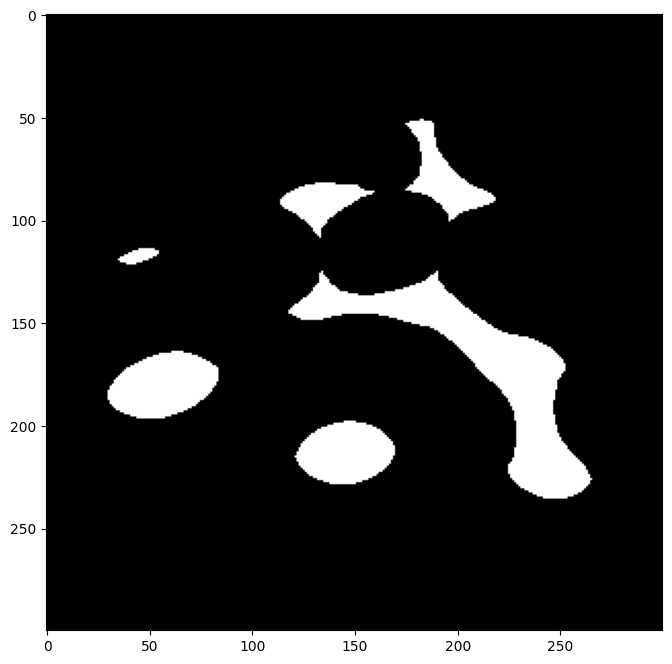

In [27]:
display(sure_fg, cmap = 'gray')

### Find unknown region

In [29]:
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

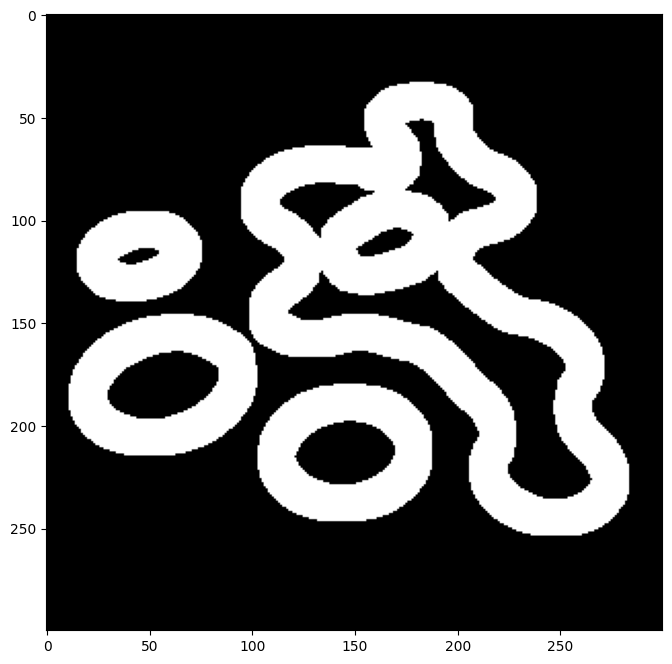

In [30]:
display(unknown, cmap = 'gray')

### Label Markers of sure Foreground

In [32]:
ret,markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

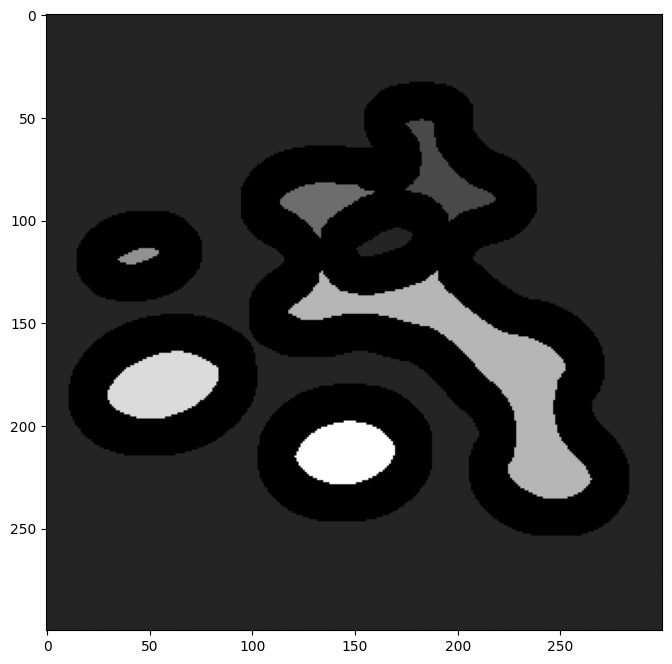

In [33]:
display(markers, cmap = 'gray')

### Apply watershed alogirithm to find markers

In [35]:
markers = cv2.watershed(img,markers)

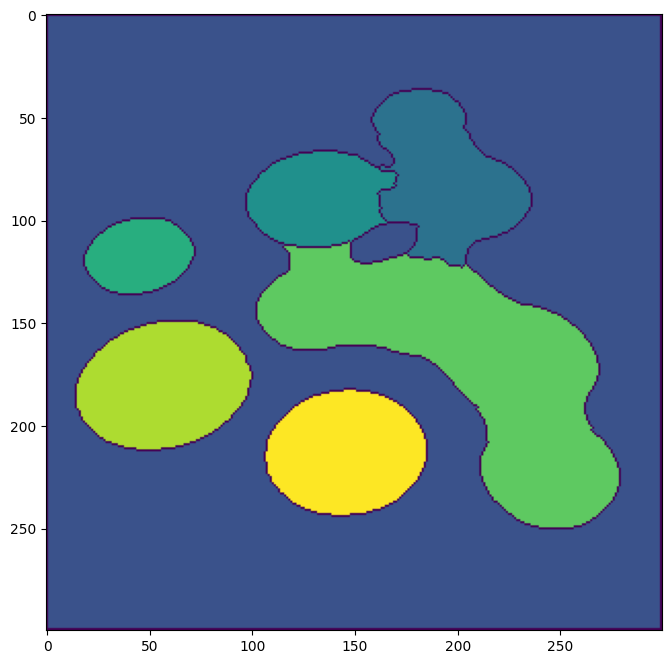

In [36]:
display(markers)

### Read the image again

In [38]:
img = cv2.imread('coins_image.jpg')

### Find contours on Markers

In [40]:
contours,hierachy = cv2.findContours(markers.copy(), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
for i in range(len(contours)):
    if hierachy[0][i][3] == -1:
        cv2.drawContours(img,contours,i,(255,0,0),10)

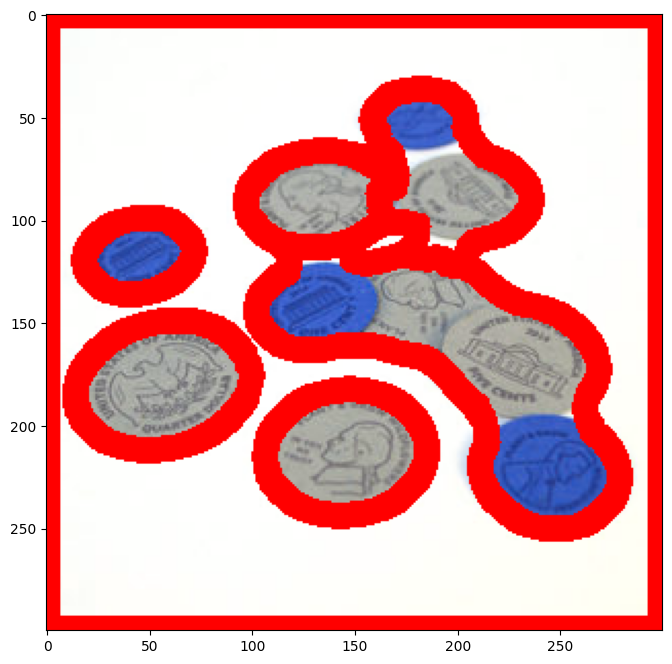

In [41]:
display(img)

***

# <span style = "color:green;font-size:40px"> Great Job!</span>